# CHIR99021 -> GSK3 -> Wnt -> stem cell fate

The model itself is JavaScript, in `../src`. This notebook drives it and plots
the results. There is deliberately **one** implementation of the biology: every
fix made to the model shows up here automatically, and there is no Python copy
to drift out of sync.

Requires Node on PATH. `stemcell.py` (next to this file) does the plumbing.

In [ ]:
# autoreload picks up edits to stemcell.py and make_figures.py without a kernel
# restart. Without it, `import make_figures` is a no-op once the module is in
# sys.modules, so you keep running the copy loaded at first import and get
# AttributeError for anything added since.
%load_ext autoreload
%autoreload 2

import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))

import stemcell as sc
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("model root:", sc.ROOT)

## 1. Cord blood: the dose curve is a hill instead of a ramp

7-day CD34+ culture with SCF/TPO/FLT3L. The endpoint that matters is not how
much the cells expanded but how many *engrafting units* came out per input cell
— expansion x stem frequency x homing capacity.

In [ ]:
doses = [0, 0.5, 1, 1.5, 2, 2.5, 3, 4, 5, 6, 8, 10, 12]
cb = sc.sweep(doses, model="hsc", chir_end=168, days=7)

fig, ax1 = plt.subplots()
ax1.plot(cb.index, cb["fold_expansion"], "o-", color="tab:blue", label="fold expansion")
ax1.set_xlabel("CHIR99021 (uM)"); ax1.set_ylabel("fold expansion", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx(); ax2.grid(False)
ax2.plot(cb.index, cb["engraftment"], "s-", color="tab:red", label="engraftment")
ax2.set_ylabel("engraftment per input cell", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

best = cb["engraftment"].idxmax()
ax2.axvline(best, ls="--", color="grey", lw=1)
ax2.annotate(f"optimum {best} uM", xy=(best, cb["engraftment"].max()),
             xytext=(best + 1.2, cb["engraftment"].max()), color="grey")
plt.title("Fewer cells, better cells - and past the MYC threshold, neither")
plt.tight_layout(); plt.show()

cb[["fold_expansion", "stem_frequency", "homing", "engraftment"]].round(3)

Note the shape: more CHIR keeps buying stem quality for a while, then stops.
**High-dose CHIR is worse than no CHIR at all.** If you dose this like a cardiac
protocol you will destroy the thing you are trying to expand.

## 2. Why it is a hill

Two direct Wnt target genes with *different* thresholds. HOXB4 (self-renewal)
switches on below MYC (niche exit / differentiation). Nothing asserts a bell
curve anywhere — it falls out of the gap between these two.

In [ ]:
fig, ax = plt.subplots()
ax.plot(cb.index, cb["HOXB4"], "o-", label="HOXB4  (self-renewal)")
ax.plot(cb.index, cb["MYC"], "s-", label="MYC  (niche exit)")
ax.plot(cb.index, cb["STEM"], "^-", label="stem frequency", color="black")
ax.set_xlabel("CHIR99021 (uM)"); ax.set_ylabel("level (0-1)")
ax.legend(); ax.set_title("The gap between these two thresholds sets the optimum")
plt.tight_layout(); plt.show()

**This is the measurement worth making first.** The separation between the
HOXB4 and MYC thresholds is the only thing in the model that sets where the
optimum sits. HOXB4 and MYC by qPCR across a CHIR dose range in your own CD34+
cells would pin it; everything else in the module is secondary.

## 3. Cardiac: the signal has to go ON, then OFF

Give CHIR then remove it and block Wnt, and you get heart muscle. Leave CHIR on
and you get excellent cardiac *mesoderm* and essentially zero cardiomyocytes —
the gene that makes the next step, NKX2-5, is switched off by the very signal
that built the precursor.

In [ ]:
arms = {
    "GiWi: CHIR d0-1, IWP d3-5": dict(chir=6, chir_end=24, iwp="72:120"),
    "CHIR d0-1 only":            dict(chir=6, chir_end=24, iwp="none"),
    "CHIR continuous":           dict(chir=6, chir_end=240, iwp="none"),
    "no CHIR":                   dict(chir=0, chir_end=24, iwp="none"),
}

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.5))
for label, kw in arms.items():
    d = sc.run(model="cardiac", days=10, **kw)
    axL.plot(d.index / 24, d["TCF_B"], label=label)
    axR.plot(d.index / 24, d["TNNT2"], label=label)

axL.set_xlabel("day"); axL.set_ylabel("TCF-bcat (nM)"); axL.set_title("Wnt pathway output")
axR.set_xlabel("day"); axR.set_ylabel("TNNT2"); axR.set_title("cardiomyocyte marker")
axR.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 4. A dish is not one cell

A single simulated cell flips the switch or it does not — all or nothing. Flow
cytometry gives you a percentage, and that percentage **is** the cell-to-cell
variability. Use `sc.population()` for anything you will compare to flow data.

In [ ]:
pop = pd.DataFrame([
    sc.population(model="cardiac", chir=d, chir_end=24, iwp="72:120", days=10, cells=120)
    for d in [0, 2, 3, 4, 6, 8, 12, 16, 20]
], index=[0, 2, 3, 4, 6, 8, 12, 16, 20])
pop.index.name = "chir_uM"

fig, ax = plt.subplots()
ax.plot(pop.index, pop["pct_TNNT2"], "o-", label="% TNNT2+ of survivors")
ax.plot(pop.index, pop["yield_TNNT2"], "s-", label="% per input cell")
ax.plot(pop.index, pop["viability"] * 100, "^-", label="viability %", color="grey")
ax.set_xlabel("CHIR99021 (uM)"); ax.set_ylabel("percent")
ax.legend(); ax.set_title("Rising limb = efficiency, falling limb = toxicity")
plt.tight_layout(); plt.show()

## 5. Putting your own data next to it

`data/template.csv` is the format. Replace the placeholder numbers with your
measurements, then either plot them against the model here or run a proper fit:

```
node experiments/09_fit_mydata.js --data data/mine.csv --model hsc
```

See `data/README.md` for which parameters to fit against which assay — fitting
everything against everything gives a good SSE and meaningless parameters.

In [ ]:
obs = pd.read_csv(sc.ROOT / "data" / "template.csv", comment="#")
print("PLACEHOLDER numbers - replace these before drawing any conclusion")
obs.head(12)

In [ ]:
# Any experiment script, straight into the notebook.
print(sc.experiment("07_iwr_vs_iwp")[:1600])

In [ ]:
import make_figures as mf

# Every fig_* returns a Figure, so each call draws the plot here AND writes
# the PNG to out/figures/.
figs = mf.all_figures(dpi=200)
list(figs)

In [2]:
import sys
!{sys.executable} make_figures.py --dpi 300

writing figures to out\figures/ at 300 dpi

  out\figures\01_cordblood_dose.png
  out\figures\02_threshold_gap.png
  out\figures\03_cardiac_biphasic.png
  out\figures\04_cardiac_bell.png
  out\figures\05_gsk3_occupancy.png

done


## 6. Generating all the figures

Every `fig_*` function takes `dpi` and returns a matplotlib Figure. In a
notebook that means each call **writes the PNG to `out/figures/` and draws the
plot inline**, so one cell gives you both.

In [ ]:
import make_figures as mf

figs = mf.all_figures(dpi=200)      # all five, drawn below and saved as PNGs
list(figs)

Or one at a time, which is what you want while tweaking a single plot —
the shared cord blood simulation is cached, so the second call is instant:

```python
mf.fig_cordblood_dose(dpi=300)     # just this one, at print resolution
mf.fig_cardiac_bell(cells=200)     # same figure, bigger ensemble = smoother
```

The underlying numbers are there too, if you want the table rather than the plot:

In [2]:
cb = mf.cordblood_sweep()           # cached DataFrame behind figures 1 and 2
cb[["fold_expansion", "stem_frequency", "homing", "engraftment"]].round(3)

,fold_expansion,stem_frequency,homing,engraftment
chir_uM,,,,
0.0,47.996,0.119,0.478,2.738
0.5,38.657,0.199,0.554,4.263
1.0,30.605,0.262,0.619,4.963
1.5,24.316,0.295,0.671,4.802
2.0,19.610,0.303,0.710,4.206
2.5,16.112,0.296,0.740,3.507
3.0,13.471,0.282,0.763,2.855
4.0,9.791,0.249,0.794,1.842
5.0,7.310,0.221,0.814,1.166


### From a terminal instead

Same code, headless, straight to files. Note this is a **shell** command, so in
a cell it needs a leading `!` and no `notebooks/` prefix — the kernel already
runs in this directory:

```python
import sys
!{sys.executable} make_figures.py --dpi 300
```

  out\figures\01_cordblood_dose.png
  out\figures\02_threshold_gap.png
  out\figures\03_cardiac_biphasic.png
  out\figures\04_cardiac_bell.png
  out\figures\05_gsk3_occupancy.png


['cordblood_dose',
 'threshold_gap',
 'cardiac_biphasic',
 'cardiac_bell',
 'gsk3_occupancy']

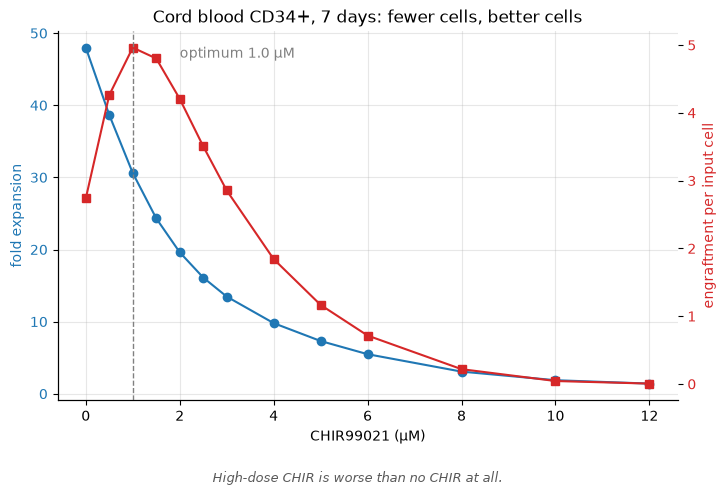

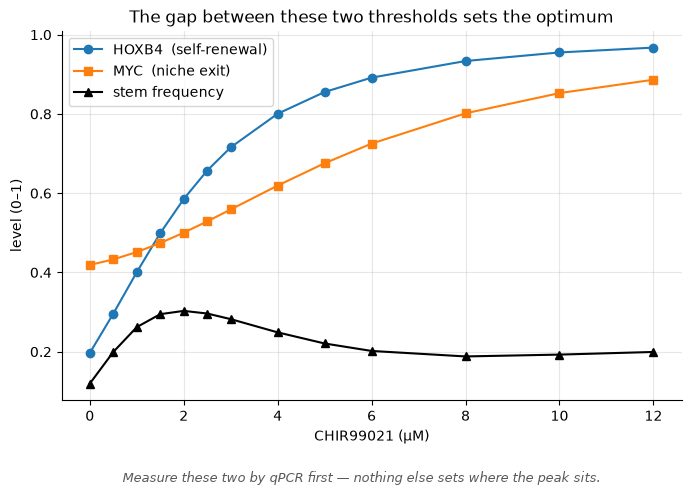

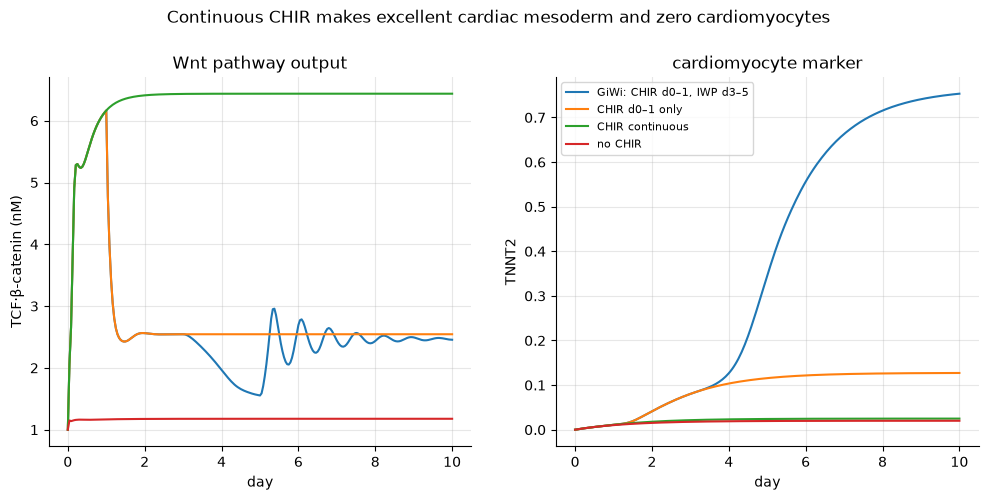

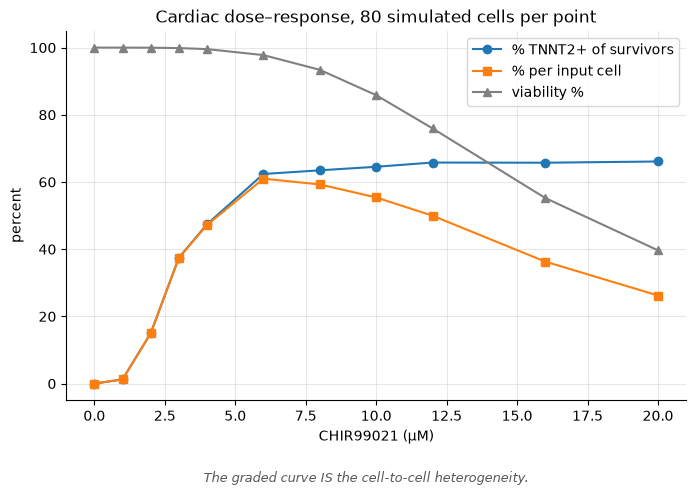

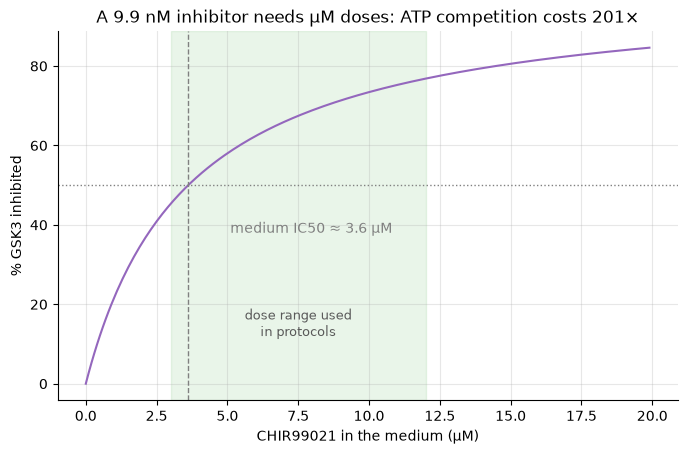

In [1]:
import make_figures as mf

figs = mf.all_figures(dpi=200)
list(figs)